In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/healthcare_dataset (2).csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

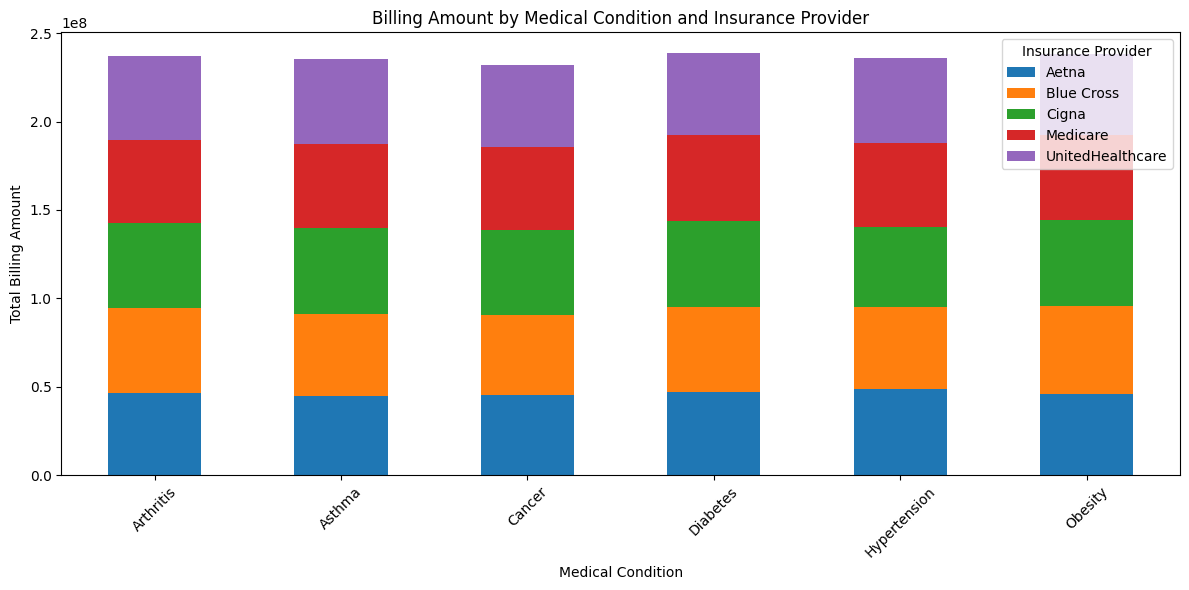

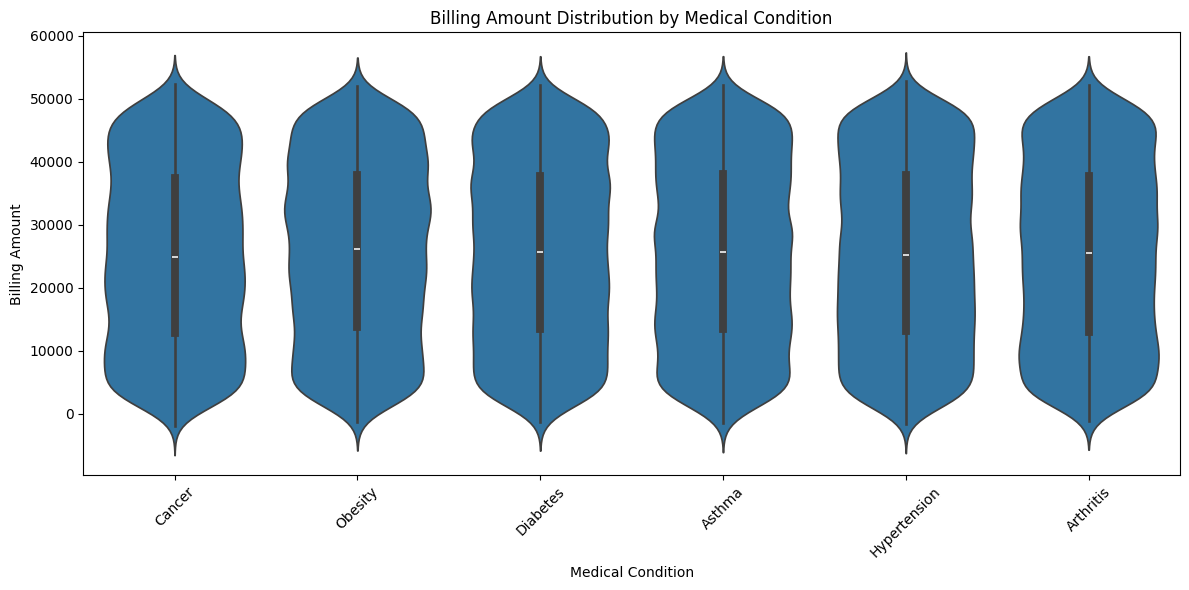

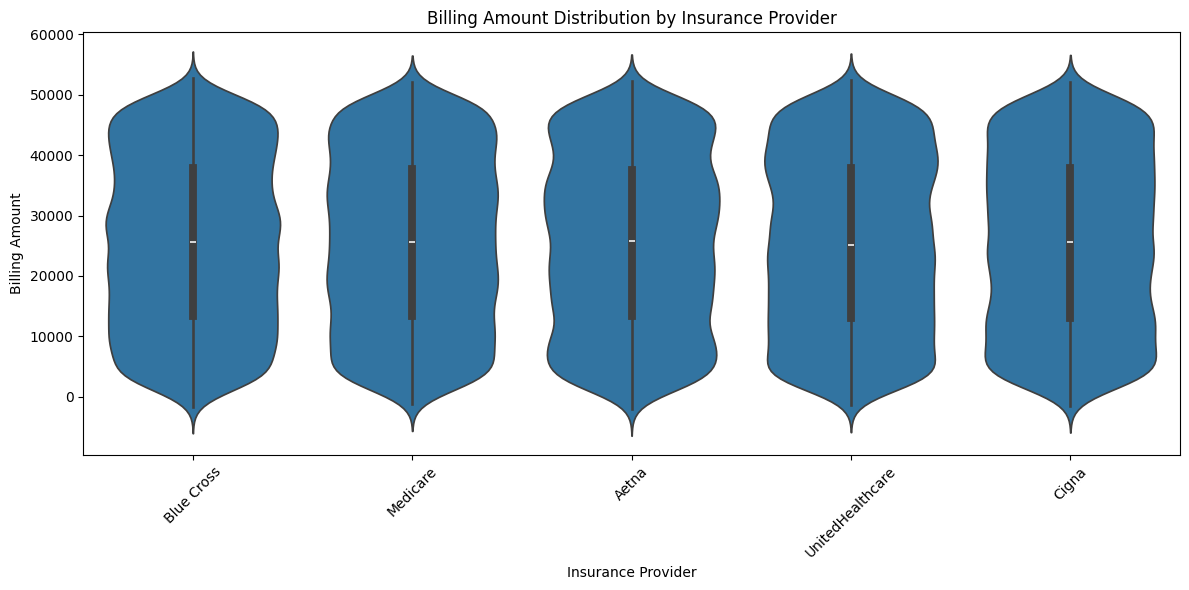

Average Billing Amount by Medical Condition:
Medical Condition
Arthritis       25497.327056
Asthma          25635.249359
Cancer          25161.792707
Diabetes        25638.405577
Hypertension    25497.095761
Obesity         25805.971259
Name: Billing Amount, dtype: float64

Average Billing Amount by Insurance Provider:
Insurance Provider
Aetna               25553.294506
Blue Cross          25613.011503
Cigna               25525.766314
Medicare            25615.990508
UnitedHealthcare    25389.172390
Name: Billing Amount, dtype: float64


In [4]:
df.info()

df.describe()

df.isnull().sum()

df.columns

df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Year_Month'] = df['Date of Admission'].dt.to_period('M')
monthly_admissions = df.groupby('Year_Month').size()
monthly_admissions.head()

peak_month = monthly_admissions.idxmax()
peak_admissions = monthly_admissions.max()

print("Peak Admission Month:", peak_month)
print("Number of Admissions:", peak_admissions)

billing_data = df.groupby(
    ['Medical Condition', 'Insurance Provider']
)['Billing Amount'].sum().unstack(fill_value=0)

billing_data.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('Billing Amount by Medical Condition and Insurance Provider')
plt.xlabel('Medical Condition')
plt.ylabel('Total Billing Amount')
plt.xticks(rotation=45)
plt.legend(title='Insurance Provider')
plt.tight_layout()
plt.show()

# Removed redundant import pandas as pd, df=pd.read_csv("/content/healthcare_dataset (1).csv") and import seaborn as sns
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df,
    x='Medical Condition',
    y='Billing Amount'
)

# Removed redundant import matplotlib.pyplot as plt
plt.title('Billing Amount Distribution by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Billing Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x='Insurance Provider',
    y='Billing Amount'
)

plt.title('Billing Amount Distribution by Insurance Provider')
plt.xlabel('Insurance Provider')
plt.ylabel('Billing Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Average Billing Amount by Medical Condition:")

print(df.groupby('Medical Condition')['Billing Amount'].mean())

print("\nAverage Billing Amount by Insurance Provider:")

print(df.groupby('Insurance Provider')['Billing Amount'].mean())